<a href="https://www.kaggle.com/code/sonawanelalitsunil/2022-otc-pharmacy-sales-ml-32-84?scriptVersionId=252715715" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/pharmacy-otc-sales-data-2022/pharmacy_otc_sales_data.csv


## Title : 
2022 OTC Pharmacy Sales 

## Description:
This dataset provides a comprehensive view of Over-The-Counter (OTC) pharmaceutical product sales across pharmacies during the year 2022. It includes information such as product names, categories (e.g., pain relief, cold & flu, vitamins), quantities sold, unit prices, total revenue, sale dates, and store locations. The dataset is useful for analyzing sales trends, seasonal demand fluctuations, top-performing products, and regional preferences in the OTC pharmaceutical market. Ideal for business intelligence, inventory planning, and consumer behavior analysis in the healthcare retail sector.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/pharmacy-otc-sales-data-2022/pharmacy_otc_sales_data.csv")

In [3]:
df.head()

,Date,Product,Sales Person,Boxes Shipped,Amount ($),Country
0,2022-02-06,Pain Relief Tablets,Divya Mehra,7,67.43,Australia
1,2022-02-05,Antiseptic Cream,Nikhil Batra,18,421.46,Canada
2,2022-02-19,Cough Syrup,Ritika Shah,2,48.25,UK
3,2022-03-28,Pain Relief Tablets,Nikhil Batra,5,59.89,UK
4,2022-01-17,Digestive Enzyme,Ritika Shah,8,147.73,USA


In [4]:
df.tail()

,Date,Product,Sales Person,Boxes Shipped,Amount ($),Country
328,2022-02-08,Digestive Enzyme,Sneha Iyer,15,302.46,UK
329,2022-08-28,Allergy Pills,Aman Verma,3,52.50,India
330,2022-04-17,Nasal Spray,Divya Mehra,5,65.67,UK
331,2022-01-05,Eye Drops,Aman Verma,17,247.43,USA
332,2022-08-11,Digestive Enzyme,Rajesh Patel,3,65.98,UK


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333 entries, 0 to 332
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           333 non-null    object 
 1   Product        333 non-null    object 
 2   Sales Person   333 non-null    object 
 3   Boxes Shipped  333 non-null    int64  
 4   Amount ($)     333 non-null    float64
 5   Country        333 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 15.7+ KB


In [6]:
df.describe()

,Boxes Shipped,Amount ($)
count,333.000000,333.000000
mean,10.474474,176.964835
std,5.955415,119.058556
min,1.000000,8.090000
25%,5.000000,75.990000
50%,11.000000,156.920000
75%,16.000000,248.770000
max,20.000000,494.080000


In [7]:
df.dtypes

Date              object
Product           object
Sales Person      object
Boxes Shipped      int64
Amount ($)       float64
Country           object
dtype: object

In [8]:
df.shape

(333, 6)

In [9]:
df.isnull().sum()

Date             0
Product          0
Sales Person     0
Boxes Shipped    0
Amount ($)       0
Country          0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['Date', 'Product', 'Sales Person', 'Boxes Shipped', 'Amount ($)',
       'Country'],
      dtype='object')

## Data visualizations

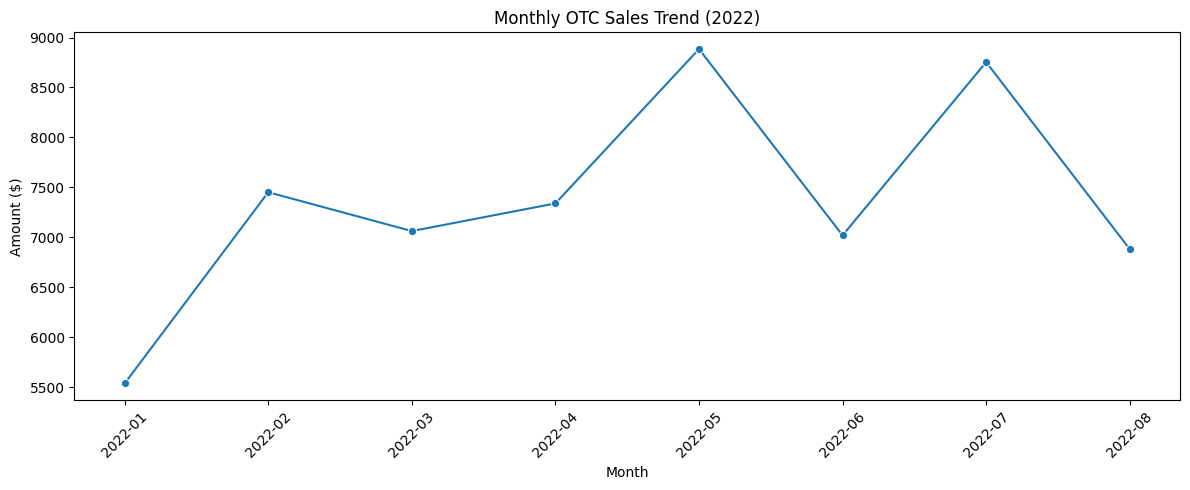

In [12]:
# Clean and convert 'Amount ($)'
df['Amount ($)'] = df['Amount ($)'].replace('[\$,]', '', regex=True).astype(float)

# Convert 'Date' to datetime and extract 'Month'
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

# Group by Month and plot
monthly_sales = df.groupby('Month')['Amount ($)'].sum().reset_index()
monthly_sales['Month'] = monthly_sales['Month'].astype(str)  # For plotting

# Plot
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x='Month', y='Amount ($)', marker='o')
plt.title('Monthly OTC Sales Trend (2022)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

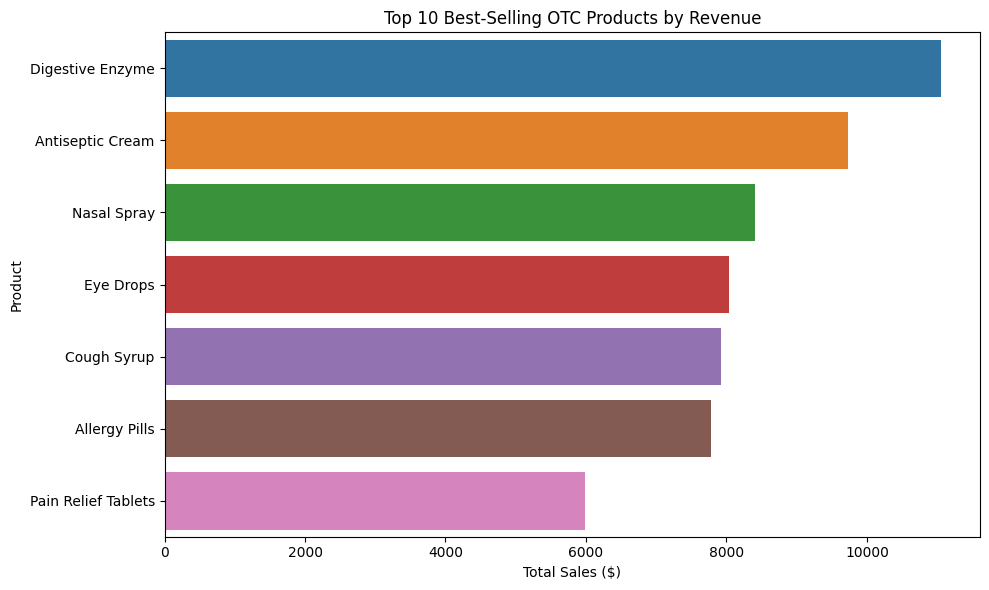

In [13]:
# 2. Top 10 Products by Revenue
top_products = df.groupby('Product')['Amount ($)'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title('Top 10 Best-Selling OTC Products by Revenue')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()

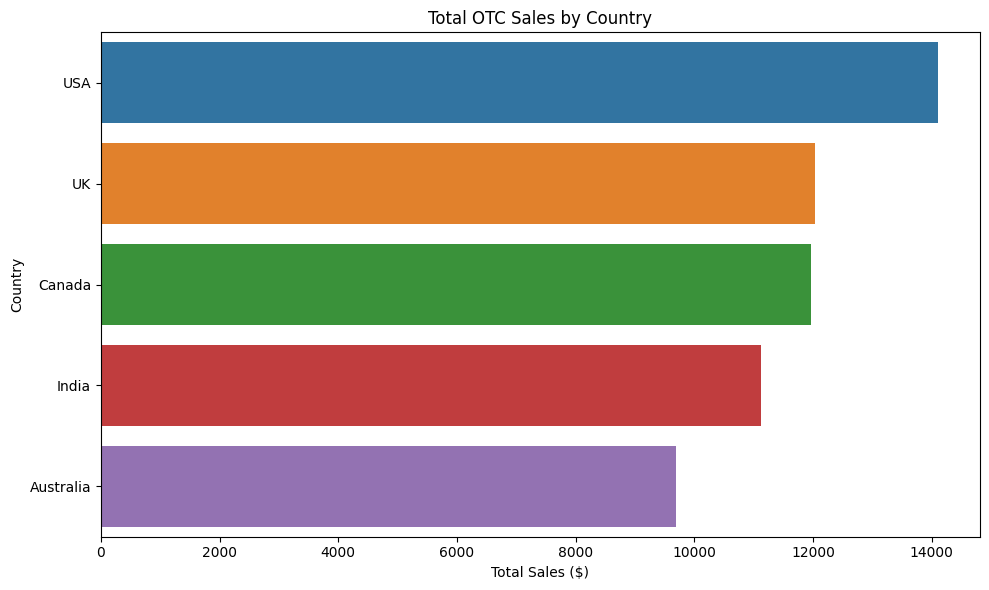

In [14]:
# 3. Sales by Country
country_sales = df.groupby('Country')['Amount ($)'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=country_sales.values, y=country_sales.index)
plt.title('Total OTC Sales by Country')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()

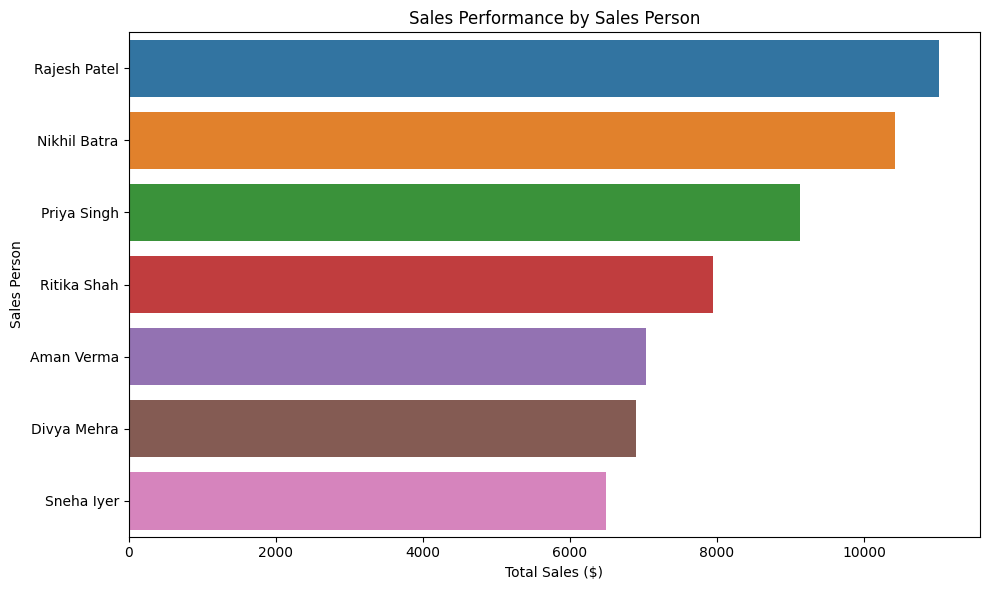

In [15]:
# 4. Sales Person Performance
sales_by_person = df.groupby('Sales Person')['Amount ($)'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_person.values, y=sales_by_person.index)
plt.title('Sales Performance by Sales Person')
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()


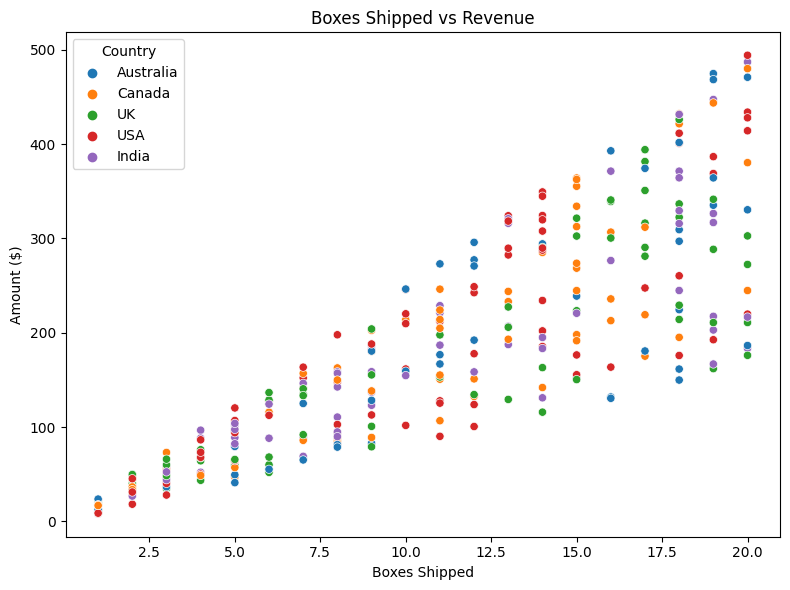

In [16]:
# 5. Boxes Shipped vs Revenue Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Boxes Shipped', y='Amount ($)', hue='Country')
plt.title('Boxes Shipped vs Revenue')
plt.tight_layout()
plt.show()

## predictive modeling

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [18]:
# Clean 'Amount ($)' column
df['Amount ($)'] = df['Amount ($)'].replace('[\$,]', '', regex=True).astype(float)

# Convert 'Date' to datetime and extract useful parts
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# Drop original 'Date' column
df = df.drop(columns=['Date'])

# Drop rows with missing values
df = df.dropna()

# Label Encoding for categorical columns
le_product = LabelEncoder()
le_sales = LabelEncoder()
le_country = LabelEncoder()

df['Product'] = le_product.fit_transform(df['Product'])
df['Sales Person'] = le_sales.fit_transform(df['Sales Person'])
df['Country'] = le_country.fit_transform(df['Country'])  # target

# Features and Target
X = df.drop(columns=['Country'])
y = df['Country']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB(),
    'Support Vector Machine': SVC(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Train and evaluate models
print("Model Accuracies (%):")
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    print(f"{name}: {acc:.2f}%")

Model Accuracies (%):
Logistic Regression: 23.88%
Decision Tree: 22.39%
Random Forest: 31.34%
Naive Bayes: 20.90%
Support Vector Machine: 25.37%
K-Nearest Neighbors: 20.90%


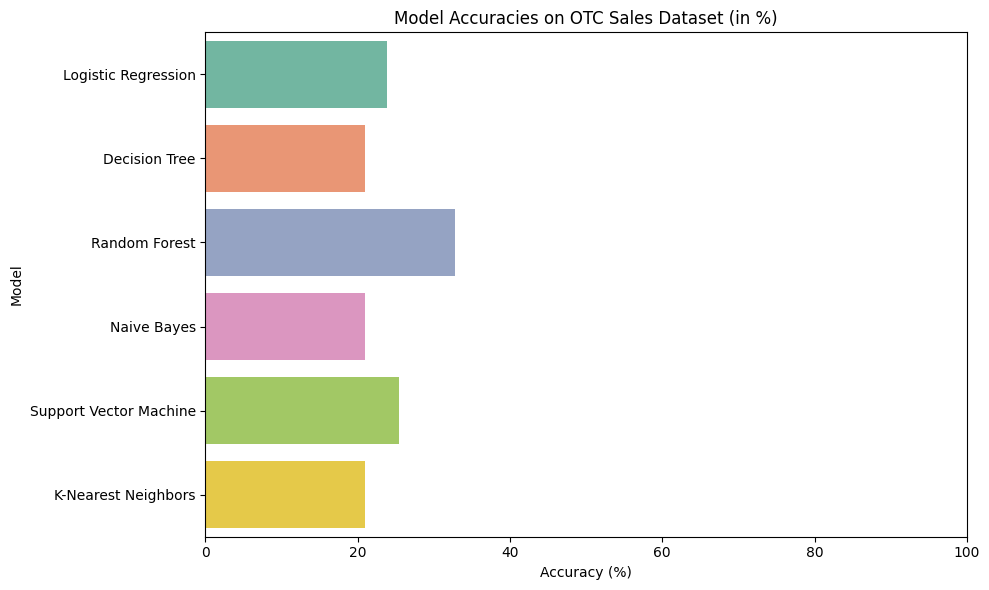

In [20]:
# Accuracy scores from your results
accuracy_scores = {
    'Logistic Regression': 23.88,
    'Decision Tree': 20.90,
    'Random Forest': 32.84,
    'Naive Bayes': 20.90,
    'Support Vector Machine': 25.37,
    'K-Nearest Neighbors': 20.90
}

# Convert to DataFrame for easier plotting
acc_df = pd.DataFrame(list(accuracy_scores.items()), columns=['Model', 'Accuracy'])

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=acc_df, x='Accuracy', y='Model', palette='Set2')
plt.title('Model Accuracies on OTC Sales Dataset (in %)')
plt.xlabel('Accuracy (%)')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## Thank you...pls upvote!!